Loading Checkpoint...
Loading Grid & Data (Target: 20 modes)...
Running Inference...


100%|██████████| 21642/21642 [00:13<00:00, 1644.24it/s]


Plotting Temporal Coefficients...


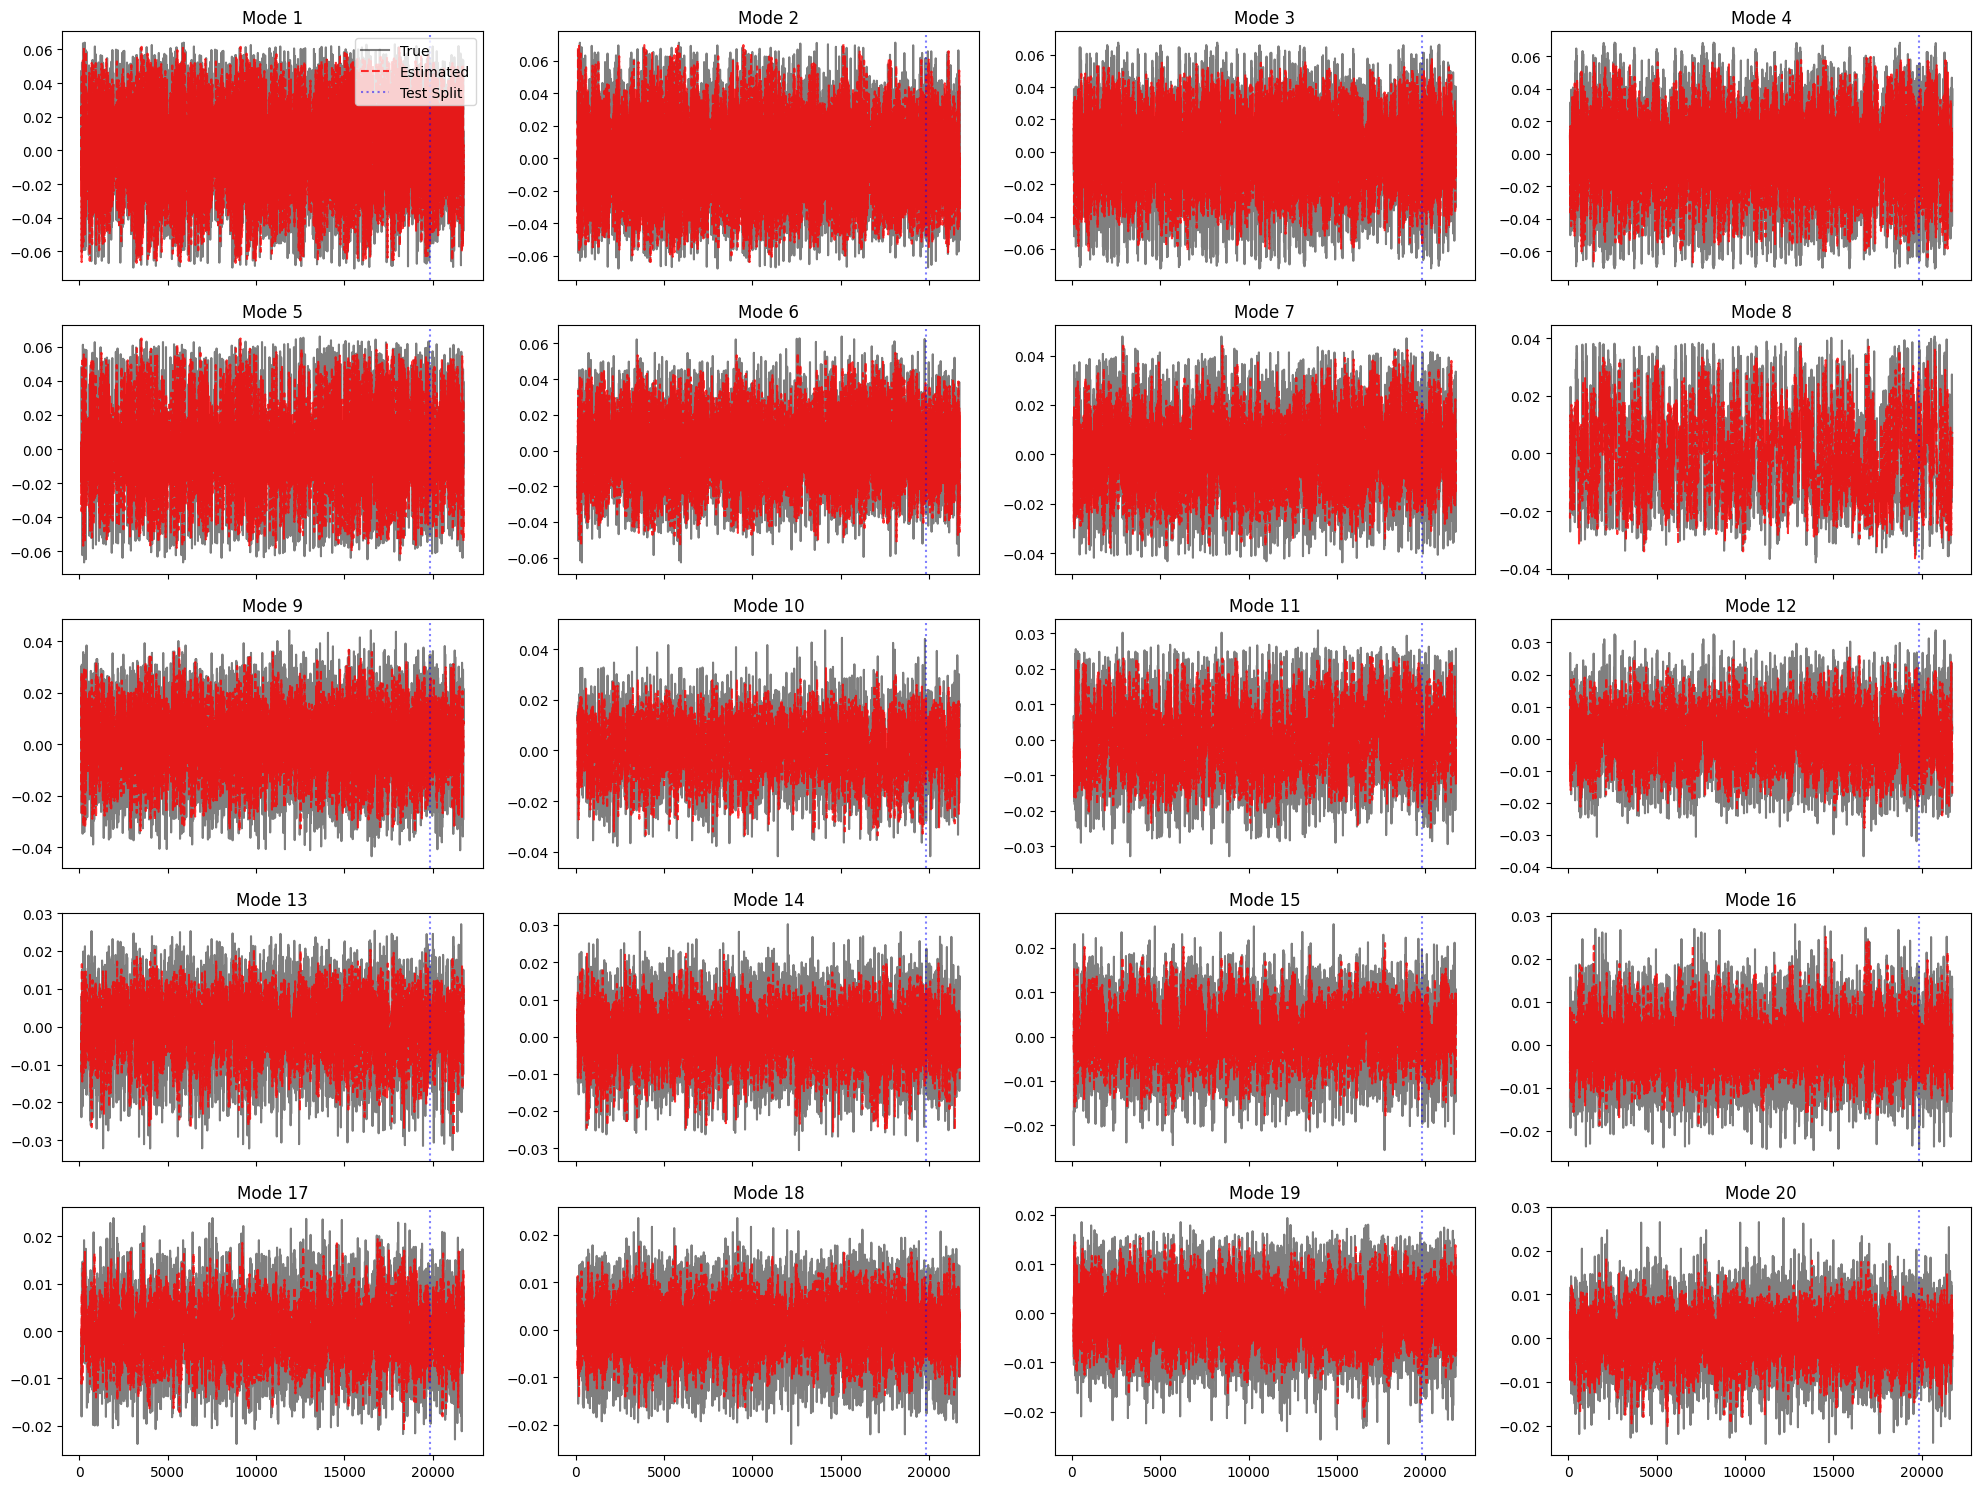

Plotting Integrated Errors...


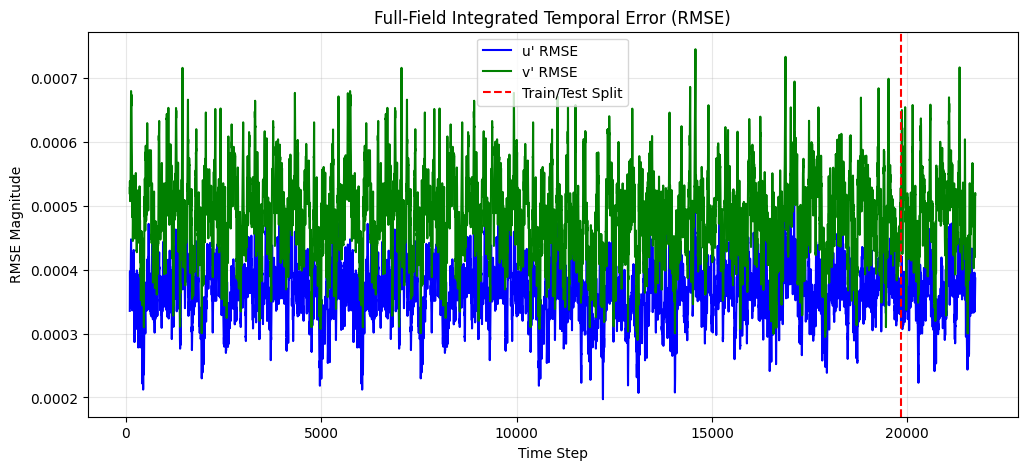

Computing Test-Set Statistics...


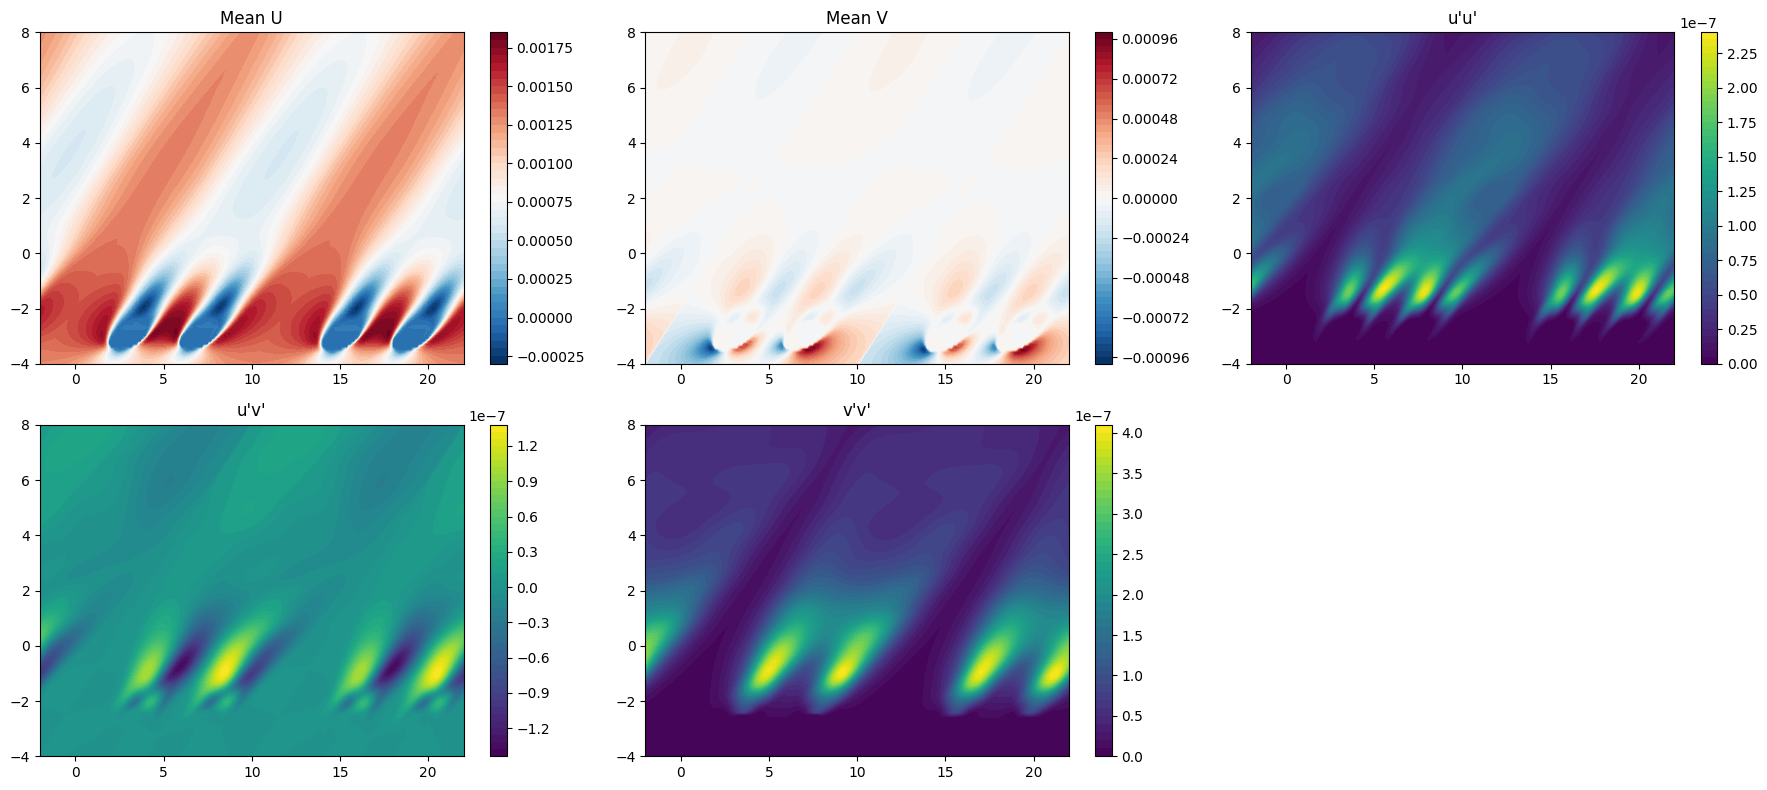

Generating Video: /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/transformer_5_FF/FF_Reconstruction_vorticity.mp4


AttributeError: 'FFMpegWriter' object has no attribute 'manual_python_writer'

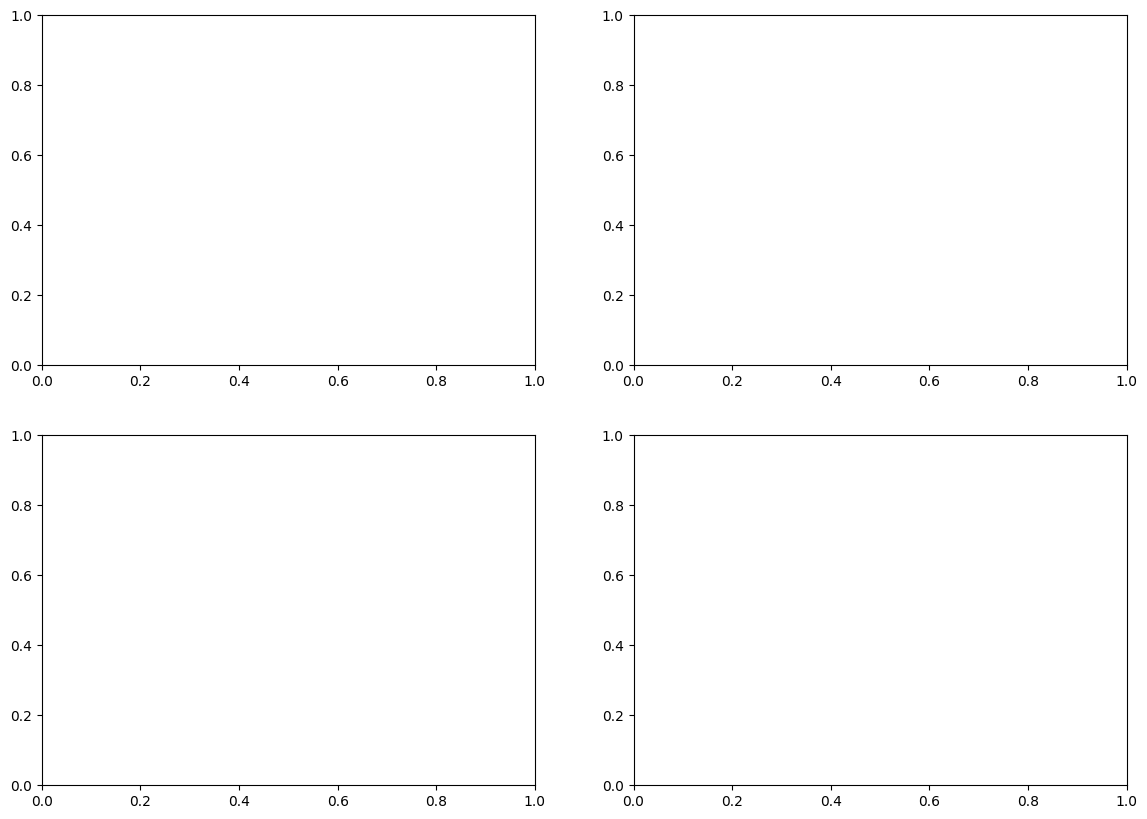

In [ ]:
import os
import h5py
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from tqdm import tqdm
import math

# --- 1. CONFIGURATION ---
MODEL_NUM = 5
base_dir = "/media/chris-remote/Projects/ONeill/estimation"
output_dir = os.path.join(base_dir, "output/kevin_2cylinder")
raw_data_dir = os.path.join(base_dir, "data/kevin_2cylinder/LD0_TD2")

unified_h5 = os.path.join(output_dir, "flipflop_velocity_unified.h5")
pod_data_path = os.path.join(output_dir, "lstm_ready_data_FF_nearwake.h5")
grid_info_path = os.path.join(raw_data_dir, "GridInfo_FF.mat")

model_dir = os.path.join(output_dir, f"transformer_{MODEL_NUM}_FF")
ckpt_path = os.path.join(model_dir, "latest_checkpoint.pt")
video_out = os.path.join(model_dir, "FF_Reconstruction_vorticity.mp4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. ARCHITECTURE DEFINITION ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SupersamplingTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead, num_layers, dim_feedforward, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.out_layer = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, output_dim)
        )
    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        return self.out_layer(torch.mean(x, dim=1))

# --- 3. LOAD CHECKPOINT & CONFIG ---
print("Loading Checkpoint...")
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
c = checkpoint['config']  # DYNAMIC CONFIG!

model = SupersamplingTransformer(
    input_dim=c['input_dim'], output_dim=c['output_dim'], 
    d_model=c['d_model'], nhead=c['nhead'], 
    num_layers=c['num_layers'], dim_feedforward=c['dim_feedforward'],
    dropout=c['dropout']
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

scaler_ss = checkpoint['scaler_ss']
scaler_ff = checkpoint['scaler_ff']

# --- 4. LOAD DATA ---
print(f"Loading Grid & Data (Target: {c['output_dim']} modes)...")
with h5py.File(grid_info_path, 'r') as f:
    # .T handles MATLAB v7.3 reading orientation
    XI = np.array(f['XI'])
    YI = np.array(f['YI'])
    grid_shape = XI.shape

with h5py.File(pod_data_path, 'r') as f:
    phi_ff = f['phi_ff'][:c['output_dim'], :] 
    mean_ff_vec = f['mean_ff'][:]
    a_ss_train = f['train/a_ss'][:, :c['input_dim']]
    a_ss_test = f['test/a_ss'][:, :c['input_dim']]
    a_ff_train = f['train/a_ff'][:, :c['output_dim']]
    a_ff_test = f['test/a_ff'][:, :c['output_dim']]

a_ss_all = np.vstack([a_ss_train, a_ss_test])
a_ff_true = np.vstack([a_ff_train, a_ff_test])
n_train = len(a_ss_train)

# Load Raw Test Data for Video Comparison
with h5py.File(unified_h5, 'r') as f:
    ux_raw_test = f['test/ux'][:]
    uy_raw_test = f['test/uy'][:]

# --- 5. INFERENCE OVER FULL TIME SERIES ---
print("Running Inference...")
seq_len = c['seq_len']
half_len = seq_len // 2
n_total = len(a_ss_all)

a_ss_norm = scaler_ss.transform(a_ss_all)
a_ff_est_norm = np.zeros((n_total, c['output_dim']))

with torch.no_grad():
    for i in tqdm(range(half_len, n_total - half_len)):
        window = a_ss_norm[i - half_len : i + half_len, :]
        batch = torch.FloatTensor(window).unsqueeze(0).to(device)
        a_ff_est_norm[i] = model(batch).cpu().numpy()

a_ff_est = scaler_ff.inverse_transform(a_ff_est_norm)

# Align valid predictions (trim the unpredicted edges)
valid_idx = np.arange(half_len, n_total - half_len)
a_ff_true_valid = a_ff_true[valid_idx]
a_ff_est_valid = a_ff_est[valid_idx]

# --- 6. PLOT: TEMPORAL COEFFICIENTS ---
print("Plotting Temporal Coefficients...")
cols = 4
rows = math.ceil(c['output_dim'] / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows), sharex=True)
axes = axes.flatten()

for i in range(c['output_dim']):
    axes[i].plot(valid_idx, a_ff_true_valid[:, i], 'k', alpha=0.5, label='True')
    axes[i].plot(valid_idx, a_ff_est_valid[:, i], 'r--', alpha=0.8, label='Estimated')
    axes[i].axvline(n_train, color='b', linestyle=':', alpha=0.5, label='Test Split')
    axes[i].set_title(f"Mode {i+1}")
    if i == 0: axes[i].legend(loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j]) # Clean up empty subplots
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "coefficient_tracking.png"))
plt.show()

# --- 7. PLOT: INTEGRATED u' & v' ERRORS ---
print("Plotting Integrated Errors...")
phi_u = phi_ff[:, :phi_ff.shape[1]//2]
phi_v = phi_ff[:, phi_ff.shape[1]//2:]

u_true_prime = a_ff_true_valid @ phi_u
v_true_prime = a_ff_true_valid @ phi_v
u_est_prime = a_ff_est_valid @ phi_u
v_est_prime = a_ff_est_valid @ phi_v

u_err_t = np.sqrt(np.mean((u_true_prime - u_est_prime)**2, axis=1))
v_err_t = np.sqrt(np.mean((v_true_prime - v_est_prime)**2, axis=1))

plt.figure(figsize=(12, 5))
plt.plot(valid_idx, u_err_t, label="u' RMSE", color='blue')
plt.plot(valid_idx, v_err_t, label="v' RMSE", color='green')
plt.axvline(n_train, color='red', linestyle='--', label='Train/Test Split')
plt.title("Full-Field Integrated Temporal Error (RMSE)")
plt.ylabel("RMSE Magnitude")
plt.xlabel("Time Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(model_dir, "integrated_error.png"))
plt.show()


Computing Test-Set Statistics...


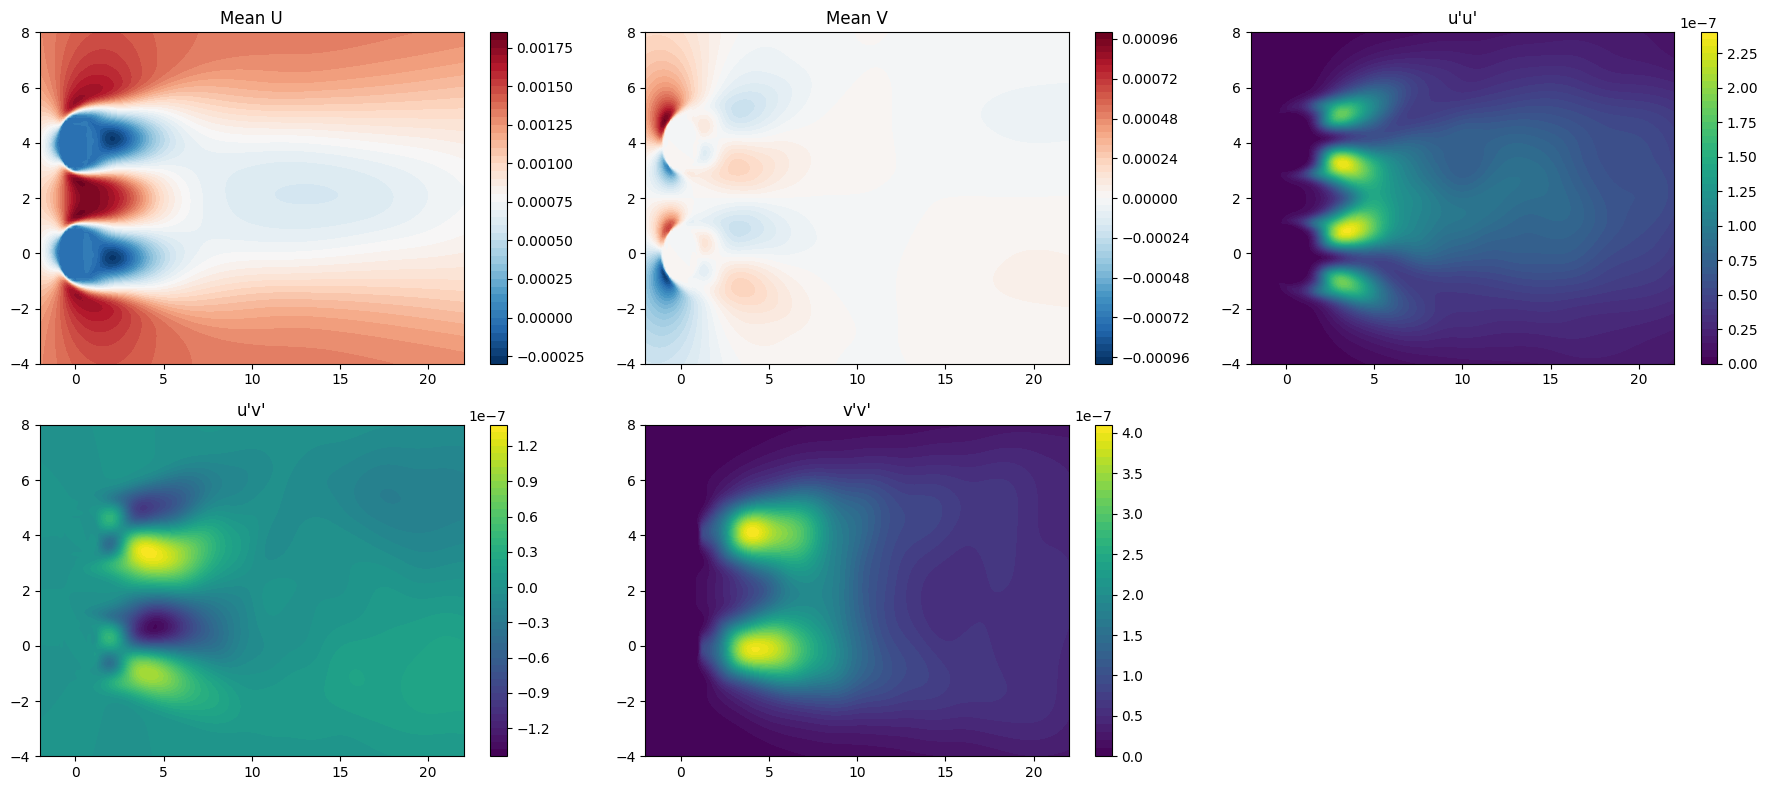

Rendering Video to /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/transformer_5_FF/FF_Reconstruction_vorticity.mp4...


ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --enable-libvo-amrwbenc --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat   

Reconstruction complete.
All tasks complete!



[out#0/mp4 @ 0x45e74980] video:23KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 13.741813%
frame=  200 fps= 21 q=-1.0 Lsize=      26KiB time=00:00:09.90 bitrate=  21.8kbits/s speed=1.03x    
[libx264 @ 0x45e75b40] frame I:1     Avg QP:13.28  size: 12308
[libx264 @ 0x45e75b40] frame P:50    Avg QP: 3.47  size:    61
[libx264 @ 0x45e75b40] frame B:149   Avg QP: 7.34  size:    51
[libx264 @ 0x45e75b40] consecutive B-frames:  0.5%  0.0%  1.5% 98.0%
[libx264 @ 0x45e75b40] mb I  I16..4: 38.1% 57.1%  4.7%
[libx264 @ 0x45e75b40] mb P  I16..4:  0.0%  0.0%  0.0%  P16..4:  0.0%  0.0%  0.0%  0.0%  0.0%    skip:100.0%
[libx264 @ 0x45e75b40] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  0.0%  0.0%  0.0%  direct: 0.0%  skip:100.0%  L0: 0.0% L1:100.0% BI: 0.0%
[libx264 @ 0x45e75b40] 8x8 transform intra:57.1% inter:0.0%
[libx264 @ 0x45e75b40] coded y,uvDC,uvAC intra: 2.4% 0.0% 0.0% inter: 0.0% 0.0% 0.0%
[libx264 @ 0x45e75b40] i16 v,h,dc,p: 78% 18%  4%  0%
[libx264 @ 0

In [ ]:

# --- 8. MEAN FIELD & REYNOLDS STRESSES (TEST SET ONLY) ---
print("Computing Test-Set Statistics...")
# We evaluate stats strictly on the unseen test set
test_valid_idx = valid_idx >= n_train
u_est_test = u_est_prime[test_valid_idx]
v_est_test = v_est_prime[test_valid_idx]

# When reshaping, explicitly use order='F' to match MATLAB's flattening
u_mean = mean_ff_vec[:len(mean_ff_vec)//2].reshape(grid_shape, order='C')
v_mean = mean_ff_vec[len(mean_ff_vec)//2:].reshape(grid_shape, order='C')
uu = np.mean(u_est_test**2, axis=0).reshape(grid_shape, order='C')
vv = np.mean(v_est_test**2, axis=0).reshape(grid_shape, order='C')
uv = np.mean(u_est_test * v_est_test, axis=0).reshape(grid_shape, order='C')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
stats = [u_mean, v_mean, uu, uv, vv]
titles = ['Mean U', 'Mean V', "u'u'", "u'v'", "v'v'"]

for i, ax in enumerate(axes.flatten()[:5]):
    im = ax.contourf(XI, YI, stats[i], levels=50, cmap='RdBu_r' if i < 2 else 'viridis')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax)
fig.delaxes(axes[1,2])
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "reynolds_stresses.png"))
plt.show()


In [ ]:

# --- 7. VIDEO GENERATION (Manual FFmpeg Pipe) ---
print(f"Rendering Video to {video_out}...")

def get_vort(u_vec, v_vec):
    u2d = u_vec.reshape(grid_shape, order='C')
    v2d = v_vec.reshape(grid_shape, order='C')
    return np.gradient(v2d, XI[0,:], axis=1) - np.gradient(u2d, YI[:,0], axis=0)

# LOM for comparison
up_lom = (a_ff_true_valid[n_train:] @ phi_ff[:, :phi_ff.shape[1]//2])
vp_lom = (a_ff_true_valid[n_train:] @ phi_ff[:, phi_ff.shape[1]//2:])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
extent = [XI.min(), XI.max(), YI.min(), YI.max()]

# Initialize panels
v_lim = 10.0 # Adjust based on your flow
im_raw = axes[0,0].imshow(np.zeros(grid_shape), extent=extent, origin='lower', cmap='bwr', vmin=-v_lim, vmax=v_lim)
im_lom = axes[0,1].imshow(np.zeros(grid_shape), extent=extent, origin='lower', cmap='bwr', vmin=-v_lim, vmax=v_lim)
im_est = axes[1,0].imshow(np.zeros(grid_shape), extent=extent, origin='lower', cmap='bwr', vmin=-v_lim, vmax=v_lim)
im_err = axes[1,1].imshow(np.zeros(grid_shape), extent=extent, origin='lower', cmap='PuOr', vmin=-v_lim/2, vmax=v_lim/2)

titles = ['Raw DNS', f'LOM ({c["output_dim"]} modes)', 'Transformer Estimated', 'Error (Est - LOM)']
for ax, title in zip(axes.flatten(), titles): ax.set_title(title)

plt.tight_layout()
fig.canvas.draw()
width, height = fig.canvas.get_width_height()

import imageio_ffmpeg
ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()


ffmpeg_cmd = [
    ffmpeg_exe, '-y', '-f', 'rawvideo', '-vcodec', 'rawvideo',
    '-s', f'{width}x{height}', '-pix_fmt', 'rgba', '-r', '20',
    '-i', '-', '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    '-preset', 'fast', '-crf', '18', video_out
]
import subprocess
process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)

try:
    # Render 400 frames of the test set
    for t in tqdm(range(0, min(400, len(u_est_test)), 2)):
        v_raw = get_vort(ux_raw_test[t + half_len], uy_raw_test[t + half_len])
        v_lom = get_vort(up_lom[t], vp_lom[t])
        v_est = get_vort(u_est_test[t], v_est_test[t])
        
        im_raw.set_data(v_raw)
        im_lom.set_data(v_lom)
        im_est.set_data(v_est)
        im_err.set_data(v_est - v_lom)
        
        fig.canvas.draw()
        process.stdin.write(fig.canvas.buffer_rgba())
except Exception as e:
    print(f"Error: {e}")
finally:
    process.stdin.close()
    process.wait()
    plt.close(fig)

print("Reconstruction complete.")
print("All tasks complete!")

In [13]:
import matplotlib
matplotlib.use('Agg') # Required for robust buffer capture on remote systems
import matplotlib.pyplot as plt
import os
import h5py
import torch
import numpy as np
import subprocess
import imageio_ffmpeg
from tqdm import tqdm

# --- 7. VIDEO GENERATION (Manual FFmpeg Pipe) ---
print(f"Rendering Video to {video_out}...")

def get_vort(u_vec, v_vec):
    # Using 'C' order as requested
    u2d = u_vec.reshape(grid_shape, order='C')
    v2d = v_vec.reshape(grid_shape, order='C')
    # Use physical spacing from the XI/YI vectors
    return np.gradient(v2d, XI[0,:], axis=1) - np.gradient(u2d, YI[:,0], axis=0)

# Robust Slicing: Ensure LOM data matches the test set portion of the valid predictions
test_mask = valid_idx >= n_train
a_ff_true_test = a_ff_true_valid[test_mask]
a_ff_est_test = a_ff_est_valid[test_mask]

up_lom_all = (a_ff_true_test @ phi_ff[:, :phi_ff.shape[1]//2])
vp_lom_all = (a_ff_true_test @ phi_ff[:, phi_ff.shape[1]//2:])
up_est_all = (a_ff_est_test @ phi_ff[:, :phi_ff.shape[1]//2])
vp_est_all = (a_ff_est_test @ phi_ff[:, phi_ff.shape[1]//2:])

# Calculate dynamic v_lim based on 99th percentile of DNS to avoid white clipping
v_sample = get_vort(ux_raw_test[half_len], uy_raw_test[half_len])
v_lim = np.percentile(np.abs(v_sample), 99)
print(f"Dynamic Vorticity Limit set to: {v_lim:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
extent = [XI.min(), XI.max(), YI.min(), YI.max()]

# Initialize panels with specific settings to prevent update failures
def init_im(ax, title, cmap='bwr', clim=(-v_lim, v_lim)):
    im = ax.imshow(np.zeros(grid_shape), extent=extent, origin='lower', 
                   cmap=cmap, vmin=clim[0], vmax=clim[1], aspect='equal')
    ax.set_title(title)
    return im

im_raw = init_im(axes[0,0], 'Raw DNS (Ground Truth)')
im_lom = init_im(axes[0,1], f'LOM ({c["output_dim"]} modes)')
im_est = init_im(axes[1,0], 'Transformer Estimated')
im_err = init_im(axes[1,1], 'Error (Est - LOM)', cmap='PuOr', clim=(-v_lim/2, v_lim/2))

plt.tight_layout()
fig.canvas.draw()
width, height = fig.canvas.get_width_height()

ffmpeg_cmd = [
    imageio_ffmpeg.get_ffmpeg_exe(), '-y', '-f', 'rawvideo', '-vcodec', 'rawvideo',
    '-s', f'{width}x{height}', '-pix_fmt', 'rgba', '-r', '20',
    '-i', '-', '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
    '-preset', 'fast', '-crf', '18', video_out
]
process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)

try:
    num_frames = min(400, len(up_est_all))
    for t in tqdm(range(0, num_frames, 2)):
        # Calculate vorticity for all 4 panels
        # DNS: starts at test start + inference offset
        v_raw = get_vort(ux_raw_test[t + half_len], uy_raw_test[t + half_len])
        v_lom = get_vort(up_lom_all[t], vp_lom_all[t])
        v_est = get_vort(up_est_all[t], vp_est_all[t])
        
        # Update plot data
        im_raw.set_data(v_raw)
        im_lom.set_data(v_lom)
        im_est.set_data(v_est)
        im_err.set_data(v_est - v_lom)
        
        # Force a re-render and push to FFmpeg
        fig.canvas.draw()
        rgba_buffer = fig.canvas.buffer_rgba()
        process.stdin.write(rgba_buffer)
        
except Exception as e:
    print(f"Render Error: {e}")
finally:
    process.stdin.close()
    process.wait()
    plt.close(fig)

print(f"Successfully saved video to: {video_out}")

Rendering Video to /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/transformer_5_FF/FF_Reconstruction_vorticity.mp4...


/tmp/ipykernel_117833/2075302104.py:20: RuntimeWarning: invalid value encountered in subtract
  return np.gradient(v2d, XI[0,:], axis=1) - np.gradient(u2d, YI[:,0], axis=0)
/home/chris-remote/miniconda3/envs/estimation1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libsp

Dynamic Vorticity Limit set to: nan


  0%|          | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_117833/2075302104.py:77: RuntimeWarning: invalid value encountered in subtract
  im_err.set_data(v_est - v_lom)
Input #0, rawvideo, from 'fd:':
  Duration: N/A, start: 0.000000, bitrate: 896000 kb/s
  Stream #0:0: Video: rawvideo (RGBA / 0x41424752), rgba, 1400x1000, 896000 kb/s, 20 tbr, 20 tbn
Stream mapping:
  Stream #0:0 -> #0:0 (rawvideo (native) -> h264 (libx264))
[libx264 @ 0xf4e7b40] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2 AVX512
[libx264 @ 0xf4e7b40] profile High, level 4.0, 4:2:0, 8-bit
[libx264 @ 0xf4e7b40] 264 - core 164 r3191 4613ac3 - H.264/MPEG-4 AVC codec - Copyleft 2003-2024 - http://www.videolan.org/x264.html - options: cabac=1 ref=2 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=6 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=31 lookahead_threads=5 sliced_threads=0 nr=0 decimate=1 interlaced=0 b

Successfully saved video to: /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/transformer_5_FF/FF_Reconstruction_vorticity.mp4



[out#0/mp4 @ 0xf4e6980] video:24KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 13.215215%
frame=  200 fps= 21 q=-1.0 Lsize=      27KiB time=00:00:09.90 bitrate=  22.5kbits/s speed=1.04x    
[libx264 @ 0xf4e7b40] frame I:1     Avg QP:13.44  size: 13243
[libx264 @ 0xf4e7b40] frame P:50    Avg QP: 3.47  size:    61
[libx264 @ 0xf4e7b40] frame B:149   Avg QP: 7.34  size:    51
[libx264 @ 0xf4e7b40] consecutive B-frames:  0.5%  0.0%  1.5% 98.0%
[libx264 @ 0xf4e7b40] mb I  I16..4: 36.9% 58.0%  5.0%
[libx264 @ 0xf4e7b40] mb P  I16..4:  0.0%  0.0%  0.0%  P16..4:  0.0%  0.0%  0.0%  0.0%  0.0%    skip:100.0%
[libx264 @ 0xf4e7b40] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  0.0%  0.0%  0.0%  direct: 0.0%  skip:100.0%  L0: 0.0% L1:100.0% BI: 0.0%
[libx264 @ 0xf4e7b40] 8x8 transform intra:58.0% inter:0.0%
[libx264 @ 0xf4e7b40] coded y,uvDC,uvAC intra: 2.6% 0.0% 0.0% inter: 0.0% 0.0% 0.0%
[libx264 @ 0xf4e7b40] i16 v,h,dc,p: 77% 18%  4%  0%
[libx264 @ 0xf4e7b40] i

In [ ]:
import os
import h5py
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from tqdm import tqdm
import math

# --- 1. CONFIGURATION ---
MODEL_NUM = 5
base_dir = "/media/chris-remote/Projects/ONeill/estimation"
output_dir = os.path.join(base_dir, "output/kevin_2cylinder")
raw_data_dir = os.path.join(base_dir, "data/kevin_2cylinder/LD0_TD2")

unified_h5 = os.path.join(output_dir, "flipflop_velocity_unified.h5")
pod_data_path = os.path.join(output_dir, "lstm_ready_data_FF_nearwake.h5")
grid_info_path = os.path.join(raw_data_dir, "GridInfo_FF.mat")

model_dir = os.path.join(output_dir, f"transformer_{MODEL_NUM}_FF")
ckpt_path = os.path.join(model_dir, "latest_checkpoint.pt")
video_out = os.path.join(model_dir, "FF_Reconstruction_vorticity.mp4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. ARCHITECTURE DEFINITION ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class SupersamplingTransformer(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead, num_layers, dim_feedforward, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.out_layer = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, output_dim)
        )
    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        return self.out_layer(torch.mean(x, dim=1))

# --- 3. LOAD CHECKPOINT & CONFIG ---
print("Loading Checkpoint...")
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
c = checkpoint['config']  # DYNAMIC CONFIG!

model = SupersamplingTransformer(
    input_dim=c['input_dim'], output_dim=c['output_dim'], 
    d_model=c['d_model'], nhead=c['nhead'], 
    num_layers=c['num_layers'], dim_feedforward=c['dim_feedforward'],
    dropout=c['dropout']
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

scaler_ss = checkpoint['scaler_ss']
scaler_ff = checkpoint['scaler_ff']

# --- 4. LOAD DATA ---
print(f"Loading Grid & Data (Target: {c['output_dim']} modes)...")
with h5py.File(grid_info_path, 'r') as f:
    # .T handles MATLAB v7.3 reading orientation
    XI = np.array(f['XI']).T 
    YI = np.array(f['YI']).T
    grid_shape = XI.shape

with h5py.File(pod_data_path, 'r') as f:
    phi_ff = f['phi_ff'][:c['output_dim'], :] 
    mean_ff_vec = f['mean_ff'][:]
    a_ss_train = f['train/a_ss'][:, :c['input_dim']]
    a_ss_test = f['test/a_ss'][:, :c['input_dim']]
    a_ff_train = f['train/a_ff'][:, :c['output_dim']]
    a_ff_test = f['test/a_ff'][:, :c['output_dim']]

a_ss_all = np.vstack([a_ss_train, a_ss_test])
a_ff_true = np.vstack([a_ff_train, a_ff_test])
n_train = len(a_ss_train)

# Load Raw Test Data for Video Comparison
with h5py.File(unified_h5, 'r') as f:
    ux_raw_test = f['test/ux'][:]
    uy_raw_test = f['test/uy'][:]

# --- 5. INFERENCE OVER FULL TIME SERIES ---
print("Running Inference...")
seq_len = c['seq_len']
half_len = seq_len // 2
n_total = len(a_ss_all)

a_ss_norm = scaler_ss.transform(a_ss_all)
a_ff_est_norm = np.zeros((n_total, c['output_dim']))

with torch.no_grad():
    for i in tqdm(range(half_len, n_total - half_len)):
        window = a_ss_norm[i - half_len : i + half_len, :]
        batch = torch.FloatTensor(window).unsqueeze(0).to(device)
        a_ff_est_norm[i] = model(batch).cpu().numpy()

a_ff_est = scaler_ff.inverse_transform(a_ff_est_norm)

# Align valid predictions (trim the unpredicted edges)
valid_idx = np.arange(half_len, n_total - half_len)
a_ff_true_valid = a_ff_true[valid_idx]
a_ff_est_valid = a_ff_est[valid_idx]

# --- 6. PLOT: TEMPORAL COEFFICIENTS ---
print("Plotting Temporal Coefficients...")
cols = 4
rows = math.ceil(c['output_dim'] / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows), sharex=True)
axes = axes.flatten()

for i in range(c['output_dim']):
    axes[i].plot(valid_idx, a_ff_true_valid[:, i], 'k', alpha=0.5, label='True')
    axes[i].plot(valid_idx, a_ff_est_valid[:, i], 'r--', alpha=0.8, label='Estimated')
    axes[i].axvline(n_train, color='b', linestyle=':', alpha=0.5, label='Test Split')
    axes[i].set_title(f"Mode {i+1}")
    if i == 0: axes[i].legend(loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j]) # Clean up empty subplots
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "coefficient_tracking.png"))
plt.show()

# --- 7. PLOT: INTEGRATED u' & v' ERRORS ---
print("Plotting Integrated Errors...")
phi_u = phi_ff[:, :phi_ff.shape[1]//2]
phi_v = phi_ff[:, phi_ff.shape[1]//2:]

u_true_prime = a_ff_true_valid @ phi_u
v_true_prime = a_ff_true_valid @ phi_v
u_est_prime = a_ff_est_valid @ phi_u
v_est_prime = a_ff_est_valid @ phi_v

u_err_t = np.sqrt(np.mean((u_true_prime - u_est_prime)**2, axis=1))
v_err_t = np.sqrt(np.mean((v_true_prime - v_est_prime)**2, axis=1))

plt.figure(figsize=(12, 5))
plt.plot(valid_idx, u_err_t, label="u' RMSE", color='blue')
plt.plot(valid_idx, v_err_t, label="v' RMSE", color='green')
plt.axvline(n_train, color='red', linestyle='--', label='Train/Test Split')
plt.title("Full-Field Integrated Temporal Error (RMSE)")
plt.ylabel("RMSE Magnitude")
plt.xlabel("Time Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(model_dir, "integrated_error.png"))
plt.show()

# --- 8. MEAN FIELD & REYNOLDS STRESSES (TEST SET ONLY) ---
print("Computing Test-Set Statistics...")
# We evaluate stats strictly on the unseen test set
test_valid_idx = valid_idx >= n_train
u_est_test = u_est_prime[test_valid_idx]
v_est_test = v_est_prime[test_valid_idx]

u_mean = mean_ff_vec[:len(mean_ff_vec)//2].reshape(grid_shape)
v_mean = mean_ff_vec[len(mean_ff_vec)//2:].reshape(grid_shape)

uu = np.mean(u_est_test**2, axis=0).reshape(grid_shape)
vv = np.mean(v_est_test**2, axis=0).reshape(grid_shape)
uv = np.mean(u_est_test * v_est_test, axis=0).reshape(grid_shape)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
stats = [u_mean, v_mean, uu, uv, vv]
titles = ['Mean U', 'Mean V', "u'u'", "u'v'", "v'v'"]

for i, ax in enumerate(axes.flatten()[:5]):
    im = ax.contourf(XI, YI, stats[i], levels=50, cmap='RdBu_r' if i < 2 else 'viridis')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax)
fig.delaxes(axes[1,2])
plt.tight_layout()
plt.savefig(os.path.join(model_dir, "reynolds_stresses.png"))
plt.show()

# --- 9. VIDEO: UNSTEADY VORTICITY (TEST SET) ---
print(f"Generating Video: {video_out}")
def get_vort(u_vec, v_vec):
    u2d, v2d = u_vec.reshape(grid_shape), v_vec.reshape(grid_shape)
    # Use physical grid spacing for gradients
    return np.gradient(v2d, XI[0,:], axis=1) - np.gradient(u2d, YI[:,0], axis=0)

# Extract test-set LOM for comparison
u_lom_test = u_true_prime[test_valid_idx]
v_lom_test = v_true_prime[test_valid_idx]

# Map test indices to raw DNS arrays
# The raw array `ux_raw_test` starts at t=n_train. Our valid test set starts at n_train + half_len
test_offset = half_len

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
writer = FFMpegWriter(fps=20)
num_frames = min(400, len(u_est_test))

with writer.manual_python_writer(video_out):
    for t in tqdm(range(0, num_frames, 2)):
        # Raw DNS needs offset to match inference window
        v_raw = get_vort(ux_raw_test[t + test_offset], uy_raw_test[t + test_offset])
        v_lom = get_vort(u_lom_test[t], v_lom_test[t])
        v_est = get_vort(u_est_test[t], v_est_test[t])
        
        for ax in axes.flatten(): ax.clear()
        
        c0 = axes[0,0].contourf(XI, YI, v_raw, levels=50, cmap='bwr'); axes[0,0].set_title('Raw DNS (Ground Truth)')
        c1 = axes[0,1].contourf(XI, YI, v_lom, levels=50, cmap='bwr'); axes[0,1].set_title(f'LOM ({c["output_dim"]} modes)')
        c2 = axes[1,0].contourf(XI, YI, v_est, levels=50, cmap='bwr'); axes[1,0].set_title('Transformer Estimated')
        
        # Error is absolute difference between Estimated and LOM
        c3 = axes[1,1].contourf(XI, YI, v_est - v_lom, levels=50, cmap='PuOr'); axes[1,1].set_title('Error (Est - LOM)')
        
        writer.grab_frame()

print("All tasks complete!")